# Cython

Мне влом писать про Cython, когда есть [документация](https://cython.readthedocs.io/en/latest/index.html) и [Wiki](https://github.com/cython/cython/wiki), так что здесь я оставлю разные примеры и необходимые пояснения.

Я заранее поставил в виртуальное окружение [cython](https://pypi.org/project/Cython/), поэтому мне не нужно морокаться с `%pip install cython`. Но установки Cython в окружение мало, нужно загрузить его здесь как расширение.

In [1]:
%load_ext Cython

Если выполнение успешно, то в ячейках тетрадки можно использовать `%%cython` - из-за `%%` команда `cython` применится ко всей ячейке, а не только лишь к строке как с `%`.

### Факториал

Хотя есть простой пример из [документации](https://cython.readthedocs.io/en/latest/src/quickstart/build.html), но лучше покрутить на уже знакомом примере факториала. После кручений-верчений, получилась такая реализация.

In [2]:
%%cython -a
# -a/--annotate -> gen ad-hoc HTML with underlying transformations into C

cimport cython

# def - accessible in Python-space -> "Pythonic" function anyway
# `int n` is Cython, in Python would be `n: int`
#@cython.overflowcheck(True)
def factorial_cy1(int n):  # no need to use an annotation for a return value
    if n < 0:
        msg = f"{n} < 0"
        raise ValueError(msg) from None
    if n < 2:
        return 1
    cdef int i  # declare an integer `i` -> `int i`
    cdef long long f = 1  # initialise like `long long int s = 1;` 
    for i in range(2, n + 1):  # n is not expected to be overflown
        # No need for an `overflowcheck` decorator,
        # because I expect the overflow only for `f` here
        with cython.overflowcheck(True):
            f *= i
    return f

try:
    factorial_cy1(-1)
except ValueError as e:
    print(e)

for n in range(0, 21):
    print(f"{n:>2}! -> {factorial_cy1(n)}")

try:
    factorial_cy1(21)
except OverflowError as e:
    print(f"21 -> {e}")

-1 < 0
 0! -> 1
 1! -> 1
 2! -> 2
 3! -> 6
 4! -> 24
 5! -> 120
 6! -> 720
 7! -> 5040
 8! -> 40320
 9! -> 362880
10! -> 3628800
11! -> 39916800
12! -> 479001600
13! -> 6227020800
14! -> 87178291200
15! -> 1307674368000
16! -> 20922789888000
17! -> 355687428096000
18! -> 6402373705728000
19! -> 121645100408832000
20! -> 2432902008176640000


На моей машине (Ubuntu 24 LTS) переполнение наступает уже для `n = 21`: таковы ограничения типов и "long long" просто не вместил значение, а значит прошло переполнение сверху (overflow). Поскольку на разных платформах размеры типы отличаются, то не следует привязываться к числу 21 и делать "костыли" исходя из этой границы (если только именно в этом нет насущной потребности).

И всё же подобные ограничения так себе, ведь хочется работать с большими числами. Оказывается, достаточно обойтись малыми поменами:

In [3]:
%%cython --annotate

cimport cython

@cython.overflowcheck(True)
def factorial_cy2(int n):
    if n < 0:
        msg = f"{n} < 0"
        raise ValueError(msg) from None
    if n < 2:
        return 1
    cdef int i  # declare an integer `i` -> `int i`
    # f = 1  # Python object if Cython infer_types is None
    cdef object f = 1  # treat f as Python object explicitly and give no damn about infer_types 
    for i in range(2, n + 1):
        f *= i
    return f


for n in [20, 21, 22]:
    print(f"{n:>2}! -> {factorial_cy2(n)}")

20! -> 2432902008176640000
21! -> 51090942171709440000
22! -> 1124000727777607680000


Оказалось достаточным убрать ограничение `cdef long long f = 1` и рассматривать переменную `f` в качестве Python объекта. Можно ожидать меньшую производительность, но выигрышный перевес очевиден: можно считать большие числа.

### Числа Фибоначчи

С рядом Фибоначчи получилось настолько легко, что здесь нечего и оттаптываться, когда можно посмотреть имплементацию в пакете. Но стоит проверить предположение: что будет если подать Cython чисто питоновскую функцию (вот прям как есть):

In [4]:
def fib_py(nth: int) -> int:
    if nth < 1:
        msg = "n must be a positive integer"
        raise ValueError(msg) from None
    if nth < 3:
        return 1
    a, b = 1, 1
    for _ in range(2, nth):
        a, b = b, a + b
    return b


for i in range(1, 11):
    print(f"fib({i}) -> {fib_py(i)}")

fib(1) -> 1
fib(2) -> 1
fib(3) -> 2
fib(4) -> 3
fib(5) -> 5
fib(6) -> 8
fib(7) -> 13
fib(8) -> 21
fib(9) -> 34
fib(10) -> 55


А теперь то же самое, но для натравки на Cython.

In [5]:
%%cython -a

def fib_cy(nth: int) -> int:
    if nth < 1:
        msg = "n must be a positive integer"
        raise ValueError(msg) from None
    if nth < 3:
        return 1
    a, b = 1, 1
    for _ in range(2, nth):
        a, b = b, a + b
    return b

Предварительно сверимся, что эти функции дают одинаковые выдатки (результаты).

In [6]:
for nth in (1, 10, 50, 100):
    assert fib_py(nth) == fib_cy(nth)

А теперь замеры быстродействия - можно поиграться несколько раз, но в целом функция `fib_cy` всегда быстрее, хотя это обычная Python функция.

In [7]:
nth = 100

# -n -> number of runs per round
# -r -> number of rounds

%timeit -n 1000 -r 10 fib_py(nth)
%timeit -n 1000 -r 10 fib_cy(nth)

2.17 μs ± 185 ns per loop (mean ± std. dev. of 10 runs, 1,000 loops each)
1.67 μs ± 86.4 ns per loop (mean ± std. dev. of 10 runs, 1,000 loops each)


Нейронка написала за меня код для построения графика производительности функций `fib_py` и `fib_cy`.

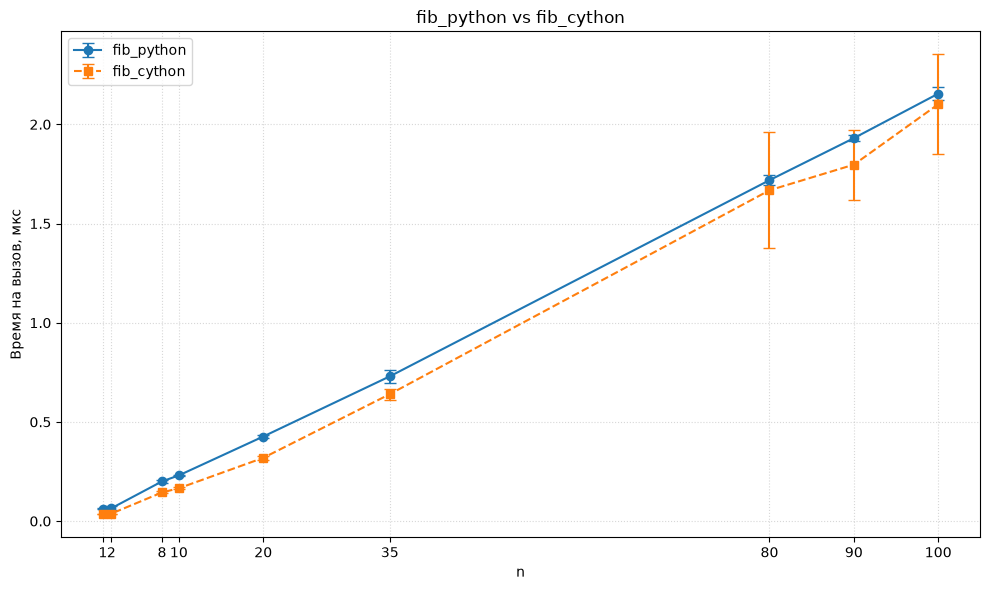

In [8]:
import timeit
import statistics
import matplotlib.pyplot as plt

ns = [1, 2, 8, 10, 20, 35, 80, 90, 100]

results_py = []   # (mean, std) в микросекундах
results_cy = []

for n in ns:
    # --- Python ---
    times_py = timeit.repeat(lambda: fib_py(n), number=1000, repeat=10)
    mean_py = statistics.mean(times_py) / 1000 * 1e6
    std_py = statistics.stdev(times_py) / 1000 * 1e6
    results_py.append((mean_py, std_py))

    # --- Cython ---
    times_cy = timeit.repeat(lambda: fib_cy(n), number=1000, repeat=10)
    mean_cy = statistics.mean(times_cy) / 1000 * 1e6
    std_cy = statistics.stdev(times_cy) / 1000 * 1e6
    results_cy.append((mean_cy, std_cy))

# --- График ---
means_py = [r[0] for r in results_py]
stds_py = [r[1] for r in results_py]
means_cy = [r[0] for r in results_cy]
stds_cy = [r[1] for r in results_cy]

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(ns, means_py, yerr=stds_py, fmt='o-', label='fib_python',
            capsize=4, linewidth=1.5, markersize=6)
ax.errorbar(ns, means_cy, yerr=stds_cy, fmt='s--', label='fib_cython',
            capsize=4, linewidth=1.5, markersize=6)

ax.set_xlabel('n')
ax.set_ylabel('Время на вызов, мкс')
ax.set_title('fib_python vs fib_cython')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Чистая Python функция, прогнанная через Cython, оказывается быстрее. Но не стоит обманываться на этом примере и думать, что стоит всё перевести на Cython и проект залетает, а значит Cython - это путь по умолчанию и нужно его прокладывать в любой проект и с самого начала. Если вкратце, то это не так, а подробнее можно посмотреть в README основного проекта, например.

На сей раз хватит, отпускаю на покаяние :)